# 🎯 8. ReAct and Tool-Using Agents

**ReAct** (Reasoning + Acting) is the most widely-used agent architecture. It combines step-by-step reasoning with tool execution in a structured loop.

In this notebook:

1. **The ReAct paper** — key insights
2. **Thought → Action → Observation** cycle
3. **ReAct from scratch** — pure Python implementation
4. **ReAct with LangGraph** — production implementation
5. **Trace inspection** — debugging agent reasoning
6. **Failure modes** — infinite loops, wrong tools

In [1]:
import os, json
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from IPython.display import display, Markdown

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL   = "gpt-4o-mini"

client = OpenAI()
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
print(f'Model: {LLM_MODEL}')

Model: gpt-4o-mini


## 8.1 The ReAct Pattern

The ReAct paper (Yao et al., 2022) showed that combining **reasoning** traces with **actions** significantly improves agent performance.

```
Thought: I need to find the population of Tokyo.
Action: search("Tokyo population 2024")
Observation: Tokyo has approximately 13.96 million people.
Thought: Now I have the answer.
Action: finish("Tokyo has approximately 13.96 million people.")
```

### Why ReAct Works

| Component | Without ReAct | With ReAct |
|-----------|-------------|------------|
| Reasoning | Hidden/implicit | Explicit thoughts |
| Actions | Fixed pipeline | Dynamic tool selection |
| Observations | Not used | Fed back to improve reasoning |
| Debugging | Black box | Full trace available |

## 8.2 Implementing ReAct from Scratch

Let's build a complete ReAct agent without any framework:

<img src="images/react-without-framework.png" width="50%" style="border-radius:10px;margin:12px 0;"/>


In [2]:
import math
from datetime import datetime

# ── Tool Definitions ──
TOOLS = {
    'calculator': {
        'fn': lambda expr: str(eval(expr, {'__builtins__': {}}, {'sqrt': math.sqrt, 'pow': pow, 'pi': math.pi})),
        'desc': 'Evaluate math expressions. Input: expression string.'
    },
    'get_time': {
        'fn': lambda: datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'desc': 'Get current date and time. No input needed.'
    },
    'search': {
        'fn': lambda query: {
            'python': 'Python is a high-level programming language created by Guido van Rossum in 1991.',
            'langraph': 'LangGraph is a framework for building stateful AI agent workflows using graph-based orchestration.',
            'react': 'ReAct is an agent pattern that combines reasoning traces with tool actions in an iterative loop.',
        }.get(query.lower().split()[0], f'No results found for: {query}'),
        'desc': 'Search for factual information. Input: search query string.'
    },
}

REACT_PROMPT = """
You are a ReAct agent.

You have access to these tools:

{tool_list}

Use this exact format:

Question: the input question

Thought: think about what to do next
Action: one of the available tool names
Action Input: the input to the tool

Observation: the result of the tool

... repeat Thought/Action/Action Input/Observation as needed ...

Thought: I now know the final answer
Final Answer: the final answer to the original question

Important rules:
- Use only ONE action per step.
- After writing Action Input, stop immediately.
- Do not write Observation yourself.
- Do not write multiple Actions in the same response.
- Observation will be added by the Python code.
- When you have enough information, write Final Answer.

Question: {question}

{agent_scratchpad}
"""

print(f'Tools available: {list(TOOLS.keys())}')

Tools available: ['calculator', 'get_time', 'search']


In [3]:
def react_agent(question: str, max_steps: int = 7, verbose: bool = True) -> str:
    """
    A complete ReAct agent built from scratch.
    """
    tool_list = '\n'.join([f'- {name}: {info["desc"]}' for name, info in TOOLS.items()])
    scratchpad = ''
    trace = []  # For debugging
    
    for step in range(1, max_steps + 1):
        if verbose:
            print(f'\n--- Step {step} ---')
        
        # Build prompt with current scratchpad
        prompt = REACT_PROMPT.format(
            tool_list=tool_list,
            question=question,
            agent_scratchpad=scratchpad
        )
        
        # Get LLM response — STOP before generating observations
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0,
            # Σταματάμε το LLM πριν γράψει Observation.
            # Στο ReAct, το Observation πρέπει να προέρχεται από πραγματική
            # εκτέλεση εργαλείου και όχι από υπόθεση/φαντασία του μοντέλου.
            stop=['Observation:']  # Critical! Prevents hallucinated observations
        )
        
        output = response.choices[0].message.content.strip()
        if verbose:
            print(output)
        
        # Check for final answer
        if 'Final Answer:' in output:
            answer = output.split('Final Answer:')[-1].strip()
            trace.append({'step': step, 'type': 'final_answer', 'content': answer})
            if verbose:
                print(f'\n[OK] Final Answer (step {step}): {answer}')
            return answer
        
        # Parse action
        if 'Action:' in output and 'Action Input:' in output:
            action = output.split('Action:')[1].split('\n')[0].strip()
            action_input = output.split('Action Input:')[1].strip()
            
            # Execute tool
            tool_info = TOOLS.get(action)
            if tool_info:
                try:
                    if action == 'get_time':
                        observation = tool_info['fn']()
                    else:
                        observation = tool_info['fn'](action_input)
                except Exception as e:
                    observation = f'Error: {e}'
            else:
                observation = f'Error: Unknown tool "{action}"'
            
            if verbose:
                print(f'Observation: {observation}')
            
            trace.append({'step': step, 'type': 'action', 'tool': action, 'input': action_input, 'observation': observation})
            scratchpad += f'{output}\nObservation: {observation}\n'
        else:
            scratchpad += output + '\n'
    
    return 'Max steps reached without final answer.'

# Test the ReAct agent
answer = react_agent('What is the square root of 256, what is the date and time now and what is LangGraph?')


--- Step 1 ---
Thought: I need to find the square root of 256 first. 
Action: calculator
Action Input: "sqrt(256)"
Observation: sqrt(256)

--- Step 2 ---
Thought: I have the square root of 256. Now, I need to get the current date and time. 
Action: get_time
Action Input:
Observation: 2026-05-25 13:09:08

--- Step 3 ---
Thought: I now need to find information about LangGraph. 
Action: search
Action Input: "LangGraph"
Observation: No results found for: "LangGraph"

--- Step 4 ---
Thought: I need to clarify what LangGraph is, as there were no results found. It might be a new or niche term. I will try searching for related terms or concepts that might provide context.
Action: search
Action Input: "LangGraph meaning or definition"
Observation: No results found for: "LangGraph meaning or definition"

--- Step 5 ---
Thought: Since I couldn't find any information on LangGraph, I will try searching for it in a different way, perhaps looking for its applications or related technologies.
Action:

## 8.3 ReAct with LangGraph — Production Implementation

LangGraph provides the same pattern with production features: checkpointing, error handling, and automatic tool execution.

<img src="images/react-with-langgraph.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

### 8.3.1 Using **create_engine**

In [4]:
# Η create_agent είναι ΑΚΡΙΒΩΣ ο τυπικός ReAct loop:
# Thought → Action → Observation, με αυτόματο tool dispatch και
# stopping condition όταν το LLM δεν παράγει tool_calls.
import math
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports sqrt, pow, abs, pi."""
    try:
        return str(eval(expression, {'__builtins__': {}},
                        {'sqrt': math.sqrt, 'pow': pow, 'pi': math.pi, 'abs': abs}))
    except Exception as e:
        return f'Error: {e}'

@tool
def search(query: str) -> str:
    """Search a knowledge base (simulated)."""
    kb = {
        'react pattern': 'ReAct combines reasoning (Thought) with acting (Action) in iterative steps.',
        'langgraph': 'LangGraph is a framework for building stateful agents using graphs.',
    }
    q = query.lower()
    for key, val in kb.items():
        if key in q:
            return val
    return 'No relevant info.'

react_app = create_agent(
    model=llm,
    tools=[calculator, search],
    system_prompt='You are a helpful assistant. Reason step by step and call tools when needed.',
    checkpointer=MemorySaver(),
)


c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
# Run the ReAct agent and inspect the trace
config = {'configurable': {'thread_id': 'react-demo-1'}}

result = react_app.invoke(
    {'messages': [HumanMessage(content='What is sqrt(625) * 4, and what is the Singleton pattern?')]},
    config=config
)

# Print full trace
print('=== FULL AGENT TRACE ===')
for i, msg in enumerate(result['messages']):
    role = msg.__class__.__name__
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f'  Step {i}: 🔧 {tc["name"]}({tc["args"]})')
    elif isinstance(msg, ToolMessage):
        print(f'  Step {i}: 👁️ Observation: {msg.content}')
    elif hasattr(msg, 'content') and msg.content:
        print(f'  Step {i}: {role}: {msg.content}')

=== FULL AGENT TRACE ===
  Step 0: HumanMessage: What is sqrt(625) * 4, and what is the Singleton pattern?
  Step 1: 🔧 calculator({'expression': 'sqrt(625) * 4'})
  Step 1: 🔧 search({'query': 'Singleton pattern'})
  Step 2: 👁️ Observation: 100.0
  Step 3: 👁️ Observation: No relevant info.
  Step 4: AIMessage: The result of \( \sqrt{625} \times 4 \) is \( 100 \).

As for the Singleton pattern, it seems I couldn't find specific information on it. However, I can explain it based on my knowledge.

The Singleton pattern is a design pattern that restricts the instantiation of a class to a single instance. This is useful when exactly one object is needed to coordinate actions across the system. The Singleton pattern typically involves:

1. A private constructor to prevent direct instantiation.
2. A static method that returns the single instance of the class.
3. A static variable that holds the instance.

This pattern is commonly used in scenarios like logging, configuration settings, or manag

### 8.3.2 Using **LangGraph**

In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import MemorySaver

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports basic arithmetic and functions like sqrt, pow."""
    try:
        result = eval(expression, {'__builtins__': {}}, {'sqrt': math.sqrt, 'pow': pow, 'pi': math.pi, 'abs': abs})
        return str(result)
    except Exception as e:
        return f'Error: {e}'

@tool
def lookup_info(topic: str) -> str:
    """Look up factual information about a topic."""
    info = {
        'react': 'ReAct (Yao et al., 2022) combines reasoning traces with actions. It outperforms pure reasoning and pure acting approaches.',
        'langgraph': 'LangGraph provides StateGraph for building agent workflows with nodes, edges, and conditional routing.',
        'agents': 'AI agents are systems that use LLMs to reason and take actions autonomously, using tools and memory.',
    }
    for key, val in info.items():
        if key in topic.lower():
            return val
    return f'No information found for: {topic}'

# Build the ReAct agent graph
react_tools = [calculator, lookup_info]
react_llm = llm.bind_tools(react_tools)

def agent_node(state: MessagesState) -> dict:
    system = SystemMessage(content=(
        'You are a ReAct agent. Think step by step. '
        'Use tools when you need factual information or calculations. '
        'After getting tool results, reason about them before answering.'
    ))
    response = react_llm.invoke([system] + state['messages'])
    return {'messages': [response]}

def should_use_tools(state: MessagesState) -> str:
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    return END

react_graph = StateGraph(MessagesState)
react_graph.add_node('agent', agent_node)
react_graph.add_node('tools', ToolNode(react_tools))

react_graph.add_edge(START, 'agent')
react_graph.add_conditional_edges('agent', should_use_tools, ['tools', END])
react_graph.add_edge('tools', 'agent')

react_app_lang = react_graph.compile(checkpointer=MemorySaver())
print('ReAct agent with checkpointing compiled!')

ReAct agent with checkpointing compiled!


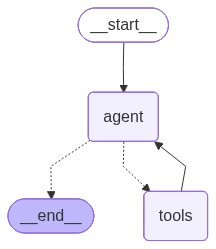

In [7]:
from IPython.display import Image, display

display(Image(react_app_lang.get_graph().draw_mermaid_png()))

In [8]:
# Run the ReAct agent and inspect the trace
config = {'configurable': {'thread_id': 'react-demo-1'}}

result = react_app.invoke(
    {'messages': [HumanMessage(content='What is sqrt(625) * 4, and what is the Panagiotis pattern?')]},
    config=config
)

# Print full trace
print('=== FULL AGENT TRACE ===')
for i, msg in enumerate(result['messages']):
    role = msg.__class__.__name__
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f'  Step {i}: 🔧 {tc["name"]}({tc["args"]})')
    elif isinstance(msg, ToolMessage):
        print(f'  Step {i}: 👁️ Observation: {msg.content}')
    elif hasattr(msg, 'content') and msg.content:
        print(f'  Step {i}: {role}: {msg.content}')

=== FULL AGENT TRACE ===
  Step 0: HumanMessage: What is sqrt(625) * 4, and what is the Singleton pattern?
  Step 1: 🔧 calculator({'expression': 'sqrt(625) * 4'})
  Step 1: 🔧 search({'query': 'Singleton pattern'})
  Step 2: 👁️ Observation: 100.0
  Step 3: 👁️ Observation: No relevant info.
  Step 4: AIMessage: The result of \( \sqrt{625} \times 4 \) is \( 100 \).

As for the Singleton pattern, it seems I couldn't find specific information on it. However, I can explain it based on my knowledge.

The Singleton pattern is a design pattern that restricts the instantiation of a class to a single instance. This is useful when exactly one object is needed to coordinate actions across the system. The Singleton pattern typically involves:

1. A private constructor to prevent direct instantiation.
2. A static method that returns the single instance of the class.
3. A static variable that holds the instance.

This pattern is commonly used in scenarios like logging, configuration settings, or manag

## 8.4 Failure Modes and Mitigations

ReAct agents can fail in several ways:

| Failure | Cause | Mitigation |
|---------|-------|------------|
| **Infinite loop** | Agent keeps calling tools without converging | Max step limit, loop detection |
| **Wrong tool** | Agent picks inappropriate tool | Better descriptions, fewer tools |
| **Hallucinated observation** | LLM generates fake tool results | `stop=['Observation:']` in generation |
| **Over-reliance on tools** | Agent calls tools for trivial questions | System prompt: "only use tools when necessary" |
| **Error cascade** | Tool error causes agent to spiral | Error handling in tool execution |

The `stop=['Observation:']` trick (from HuggingFace's agents course) is critical: it prevents the LLM from hallucinating tool results by stopping generation right before the observation, allowing real tool output to be injected.

## 💡 Exercise 8: Build a Research ReAct Agent

**Task**: Build a ReAct agent with these tools:
1. `web_search(query)` — simulated web search
2. `calculator(expression)` — math evaluation
3. `note_taker(note)` — saves notes to a list (memory)
4. `read_notes()` — reads saved notes

The agent should be able to research a topic, take notes, do calculations, and synthesize findings.

In [ ]:
# Exercise 8: YOUR CODE HERE


## 📝 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **ReAct** | Thought → Action → Observation in a loop |
| **Stop tokens** | Stop before `Observation:` to prevent hallucinated tool results |
| **LangGraph ReAct** | agent → conditional_edge → ToolNode → agent loop |
| **Checkpointing** | MemorySaver persists the full trace for debugging |
| **Failure modes** | Infinite loops, wrong tools, hallucinated observations — all preventable |

### What's Next

In **Notebook 09: Single-Agent Architectures**, we design complete, modular agent systems — combining tools, memory, planning, and ReAct into production-ready architectures.